# Final Project: SARIMA model on Monthly Taxi Data

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, glob
import pandas as pd
import numpy as np

from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from tabulate import tabulate
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Reading in Data

In [ ]:
path = '/content/drive/Shareddrives/Time Series Group 5/Final_Project/data/monthly_counts/'
all_files = glob.glob(os.path.join(path, "*.csv"))

# Create a list of DataFrames by reading each CSV file
df_list = [pd.read_csv(filename) for filename in all_files]

# Concatenate all DataFrames in the list into a single DataFrame
monthly_rides = pd.concat(df_list, ignore_index=True).drop(columns=["Unnamed: 0"])

# Display the combined DataFrame
monthly_rides.head()

,month,num_trips
0,2024-01-01T00:00:00.000,425203
1,2024-02-01T00:00:00.000,440013
2,2024-03-01T00:00:00.000,524134
3,2024-04-01T00:00:00.000,546369
4,2024-05-01T00:00:00.000,619945


## Data Cleaning
- Incomplete month of Jan 2026 was removed
- data filled via forward fill

In [ ]:
monthly_rides["month"] = pd.to_datetime(monthly_rides["month"])
monthly_rides = monthly_rides.sort_values("month")
monthly_rides_trim = monthly_rides[monthly_rides["month"] != "2026-01-01"]

ts = monthly_rides_trim.set_index("month")["num_trips"].asfreq("MS")

ts = ts.ffill()

ts.head(), ts.tail()

(month
 2013-01-01    1590062
 2013-02-01    1800402
 2013-03-01    2261377
 2013-04-01    2116671
 2013-05-01    2260977
 Freq: MS, Name: num_trips, dtype: int64,
 month
 2025-08-01    585608
 2025-09-01    623661
 2025-10-01    641251
 2025-11-01    519892
 2025-12-01    552588
 Freq: MS, Name: num_trips, dtype: int64)

### Train Test Split

In [ ]:
h = 12
train, test = ts.iloc[:-h], ts.iloc[-h:]
train.shape, test.shape

((144,), (12,))

## Preliminary Visualizations:

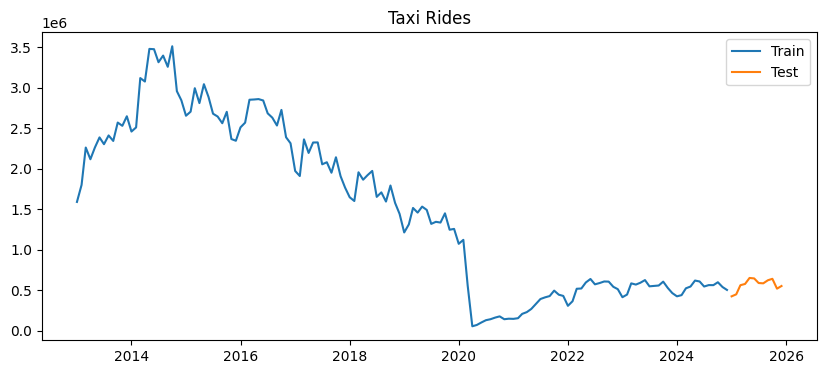

In [ ]:
# diagnostics

# visualize the series :

plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.legend()
plt.title("Taxi Rides")
plt.show()

## ACF/PACF

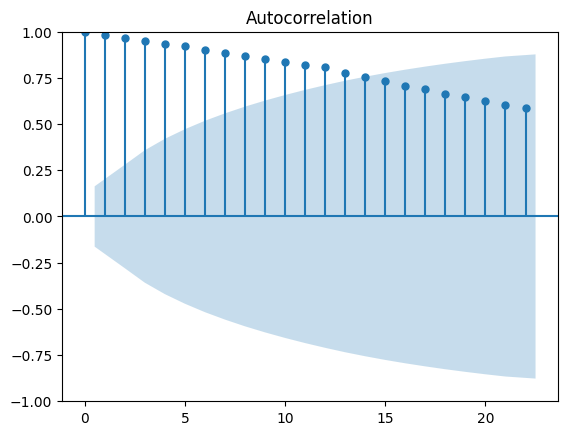

In [ ]:
plot_acf(train)
plt.show()

From ACF plot:

- Very slow decay from ~1 down to ~0.6
- No sharp cutoff
- Strong persistence across many lags
- classic non-stationary behavior (trend).
- strongly suggests: d=1, need first differencing.
- SARIMA will handle differencing internally

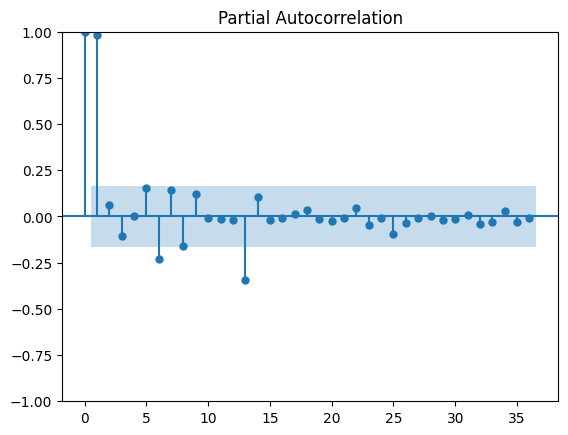

In [ ]:
plot_pacf(train, lags=36)
plt.show()

From PACF:
- Huge spike at lag 1
- Huge spike at lag 2
- smaller spike aroung 6, 12
- Everything else mostly inside the confidence band (AR(2))


Overall:
- PACF cuts off after lag 2
- ACF decays gradually
- So for the non-seasonal part: (p,d,q)=(2,1,0)


## Stationarity Testing:

In [ ]:
# Stationarity tests:
def stationarity_tests(ts):
    tables = []

    adf = adfuller(ts, autolag="AIC")
    adf_rows = [
        ("Test Statistic", adf[0]),
        ("p-value", adf[1]),
        ("Number of Lags Used", adf[2]),
        ("Number of Observations Used", adf[3]),
    ]
    for k, v in adf[4].items():
        adf_rows.append((f"Critical Value ({k})", v))

    print("ADF Test Results")
    print(tabulate(adf_rows, headers=["Metric", "Value"], tablefmt="grid"))
    print()

    kpss_res = kpss(ts, regression="c")
    kpss_rows = [
        ("Test Statistic", kpss_res[0]),
        ("p-value", kpss_res[1]),
        ("Number of Lags Used", kpss_res[2]),
    ]
    for k, v in kpss_res[3].items():
        kpss_rows.append((f"Critical Value ({k})", v))

    print("KPSS Test Results")
    print(tabulate(kpss_rows, headers=["Metric", "Value"], tablefmt="grid"))

stationarity_tests(train)

ADF Test Results
+-----------------------------+------------+
| Metric                      |      Value |
+=============================+============+
| Test Statistic              |  -1.13599  |
+-----------------------------+------------+
| p-value                     |   0.700509 |
+-----------------------------+------------+
| Number of Lags Used         |  13        |
+-----------------------------+------------+
| Number of Observations Used | 130        |
+-----------------------------+------------+
| Critical Value (1%)         |  -3.48168  |
+-----------------------------+------------+
| Critical Value (5%)         |  -2.88404  |
+-----------------------------+------------+
| Critical Value (10%)        |  -2.57877  |
+-----------------------------+------------+

KPSS Test Results
+-----------------------+---------+
| Metric                |   Value |
+=======================+=========+
| Test Statistic        | 1.46133 |
+-----------------------+---------+
| p-value          

/tmp/ipykernel_239/4072949411.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(ts, regression="c")


- ADF p > 0.05, suggesting non-stationarity
- KPSS p < 0.05, suggesting non-stationarity

## Baseline SARIMA model:

                                     SARIMAX Results                                      
Dep. Variable:                          num_trips   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1543.655
Date:                            Wed, 04 Mar 2026   AIC                           3097.309
Time:                                    16:55:21   BIC                           3111.120
Sample:                                01-01-2013   HQIC                          3102.917
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3401      0.814      0.418      0.676      -1.255       1.935
ma.L1         -0.1341      0.811   

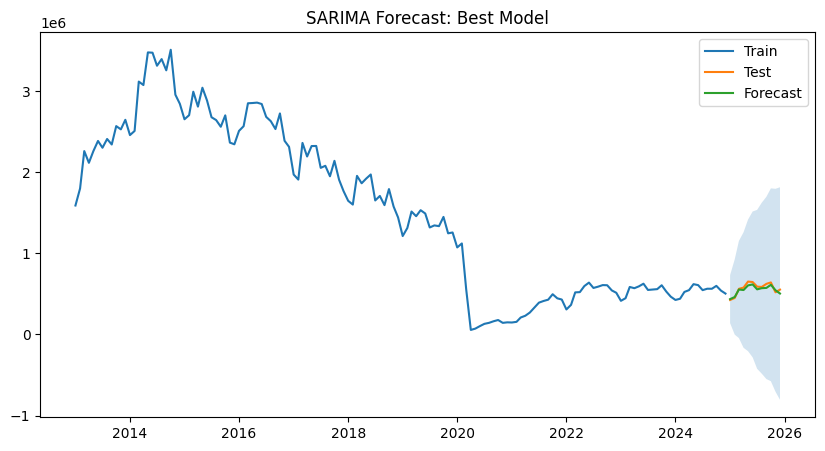

MAE: 28201.370244583362
RMSE: 31525.586121729382


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()
print(results.summary())

forecast = results.get_forecast(steps=len(test))
base_pred = forecast.predicted_mean
conf_int = forecast.conf_int()


base_mae = mean_absolute_error(test, base_pred)
base_rmse = np.sqrt(mean_squared_error(test, base_pred))

plt.figure(figsize=(10,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, base_pred, label='Forecast')
plt.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast: Best Model")
plt.show()

print("MAE:", base_mae)
print("RMSE:", base_rmse)

# Iterative SARIMA modeling

In [ ]:
import itertools

orders = [(1,1,0),(2,1,0),(1,1,1),(2,1,1)]
seasonal_orders = [(0,1,0,12),(0,1,1,12),(1,1,0,12),(1,1,1,12)]

results_table = []

for order in orders:
    for seas in seasonal_orders:
        try:
            model = SARIMAX(train, order=order, seasonal_order=seas,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            res = model.fit(disp=False)
            results_table.append((order, seas, res.aic, res.bic))
        except:
            continue

for r in sorted(results_table, key=lambda x: x[2]):
    print(r)

((1, 1, 1), (0, 1, 1, 12), np.float64(3095.3217711000466), np.float64(3106.3704668392375))
((2, 1, 1), (0, 1, 1, 12), np.float64(3097.1980719146263), np.float64(3111.008941588615))
((1, 1, 1), (1, 1, 1, 12), np.float64(3097.3094886143626), np.float64(3111.1203582883513))
((2, 1, 0), (1, 1, 1, 12), np.float64(3097.343921529733), np.float64(3111.1547912037217))
((2, 1, 1), (1, 1, 1, 12), np.float64(3099.1864997989715), np.float64(3115.759543407758))
((2, 1, 0), (1, 1, 0, 12), np.float64(3106.8929039259947), np.float64(3117.9415996651855))
((2, 1, 1), (1, 1, 0, 12), np.float64(3108.793303788396), np.float64(3122.6041734623846))
((1, 1, 0), (0, 1, 1, 12), np.float64(3120.2503397596806), np.float64(3128.5623936330776))
((2, 1, 0), (0, 1, 1, 12), np.float64(3121.4839302729497), np.float64(3132.566668770812))
((1, 1, 0), (1, 1, 1, 12), np.float64(3122.223180997352), np.float64(3133.3059194952143))
((1, 1, 0), (1, 1, 0, 12), np.float64(3133.7053424378837), np.float64(3142.0173963112807))
((1, 

In [ ]:
best_models = [
    ((1,1,1),(0,1,1,12)),
    ((2,1,1),(0,1,1,12)),
    ((1,1,1),(1,1,1,12)),
]

In [ ]:
mae_rmse_table = []

for order, seasonal in best_models:

    iterative_model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    iterative_results = iterative_model.fit(disp=False)

    forecast = iterative_results.get_forecast(steps=len(test))
    iterative_pred = forecast.predicted_mean

    it_mae = mean_absolute_error(test, iterative_pred)
    it_rmse = np.sqrt(mean_squared_error(test, iterative_pred))

    mae_rmse_table.append((order, seasonal, it_mae, it_rmse))

mae_rmse_table = sorted(mae_rmse_table, key=lambda x: x[3])


iterative_results = pd.DataFrame(mae_rmse_table, columns=["Order","Seasonal","MAE","RMSE"])
iterative_results


,Order,Seasonal,MAE,RMSE
0,"(1, 1, 1)","(1, 1, 1, 12)",28201.370245,31525.586122
1,"(2, 1, 1)","(0, 1, 1, 12)",28360.682975,31609.335891
2,"(1, 1, 1)","(0, 1, 1, 12)",28461.268690,31744.903248


Multiple SARIMA specifications yielded identical out-of-sample forecast accuracy, indicating that additional AR and seasonal AR terms did not materially improve predictive performance. Following the principle of parsimony and supported by the lowest AIC/BIC values, the SARIMA(1,1,1)×(1,1,1)_{12} model was selected as the final specification.

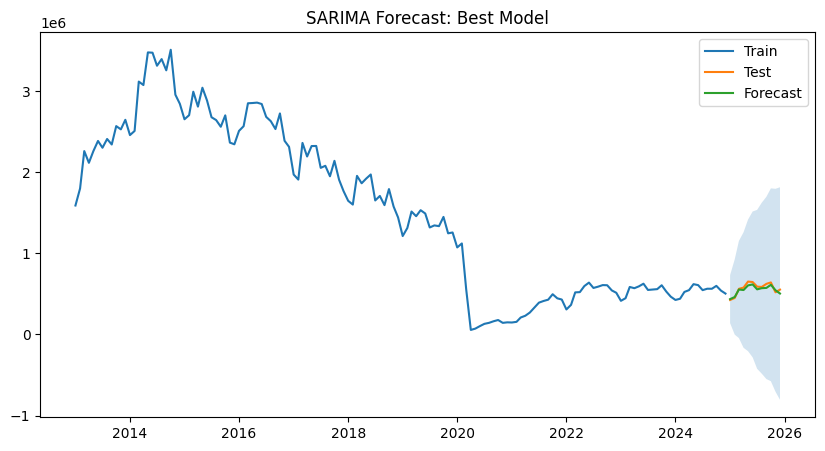

MAE: 28201.370244583362
RMSE: 31525.586121729382


In [ ]:
best_order= (1,1,1)
best_seasonal = (1,1,1,12)

best_model = SARIMAX(
        train,
        order=best_order,
        seasonal_order=best_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

best_results = best_model.fit(disp=False)

best_forecast = best_results.get_forecast(steps=len(test))
best_pred = best_forecast.predicted_mean

best_mae = mean_absolute_error(test, best_pred)
best_rmse = np.sqrt(mean_squared_error(test, best_pred))

plt.figure(figsize=(10,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, best_pred, label='Forecast')
plt.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast: Best Model")
plt.show()

print("MAE:", best_mae)
print("RMSE:", best_rmse)

### SARIMA model on covid data -- onward

In [ ]:
post_covid_df = ts.loc[ts.index >= "2020-03-01"]

post_covid_df.head()

,num_trips
month,
2020-03-01,557579
2020-04-01,55623
2020-05-01,71660
2020-06-01,102830
2020-07-01,130557


In [ ]:
h = 12
post_covid_train, post_covid_test = post_covid_df.iloc[:-h], post_covid_df.iloc[-h:]
post_covid_train.shape, post_covid_test.shape

((58,), (12,))

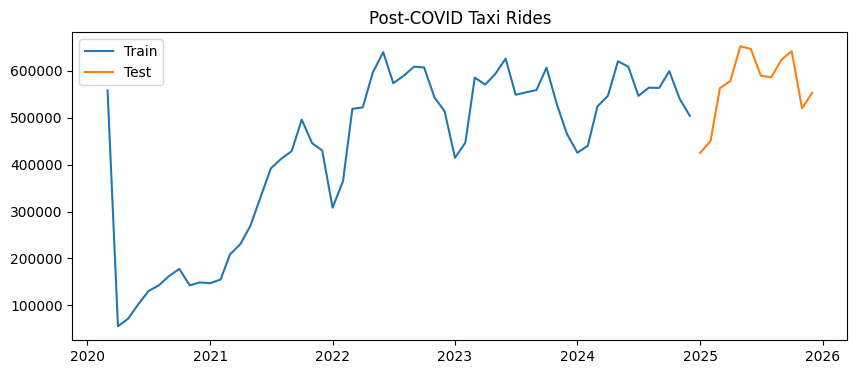

In [ ]:
# visualize the series :

plt.figure(figsize=(10,4))
plt.plot(post_covid_train, label="Train")
plt.plot(post_covid_test, label="Test")
plt.legend()
plt.title("Post-COVID Taxi Rides")
plt.show()

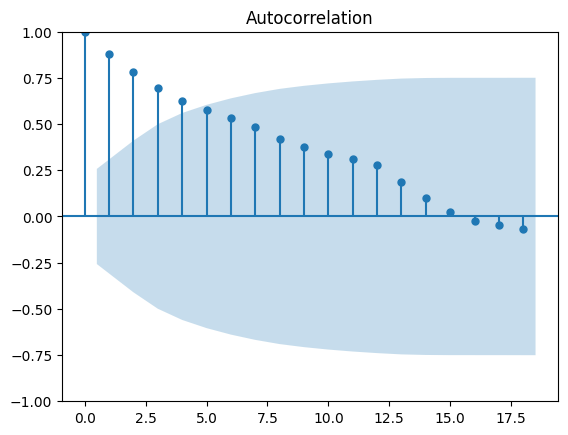

In [ ]:
plot_acf(post_covid_train)
plt.show()

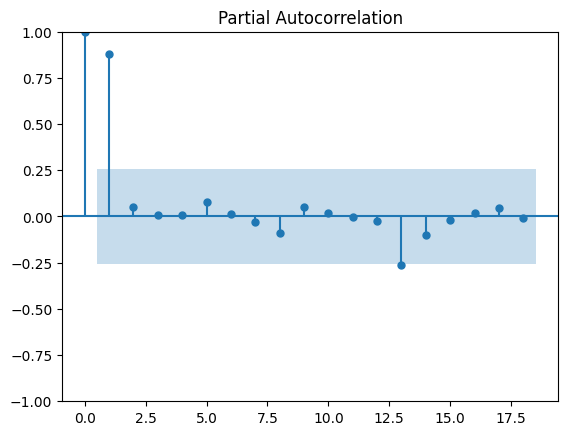

In [ ]:
plot_pacf(post_covid_train)
plt.show()

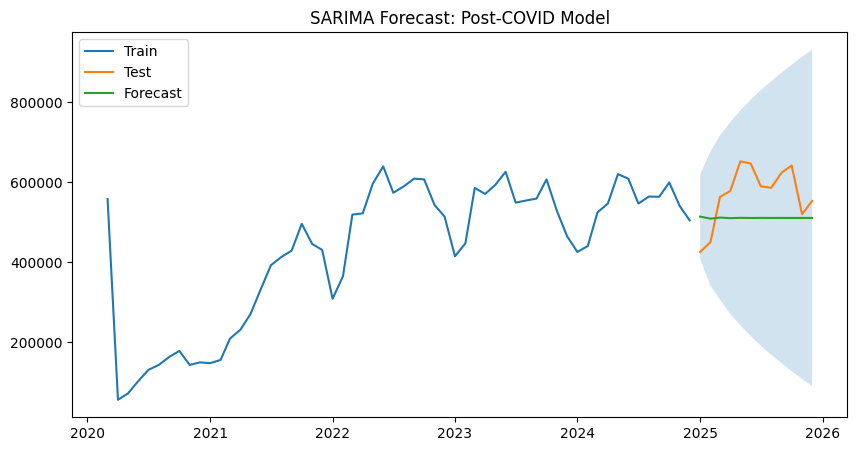

MAE: 82893.81292333255
RMSE: 91683.06155730932


In [ ]:
order= (1,1,1)
#seasonal = (1,1,1,12)

best_model = SARIMAX(
        post_covid_train,
        order=order,
        #seasonal_order=seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

best_results = best_model.fit(disp=False)

best_forecast = best_results.get_forecast(steps=len(post_covid_test))
best_pred = best_forecast.predicted_mean
conf_int = best_forecast.conf_int()

best_mae = mean_absolute_error(post_covid_test, best_pred)
best_rmse = np.sqrt(mean_squared_error(post_covid_test, best_pred))

plt.figure(figsize=(10,5))
plt.plot(post_covid_train.index, post_covid_train, label='Train')
plt.plot(post_covid_test.index, post_covid_test, label='Test')
plt.plot(post_covid_test.index, best_pred, label='Forecast')
plt.fill_between(post_covid_test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast: Post-COVID Model")
plt.show()

print("MAE:", best_mae)
print("RMSE:", best_rmse)

exog var experimenting (not successful)

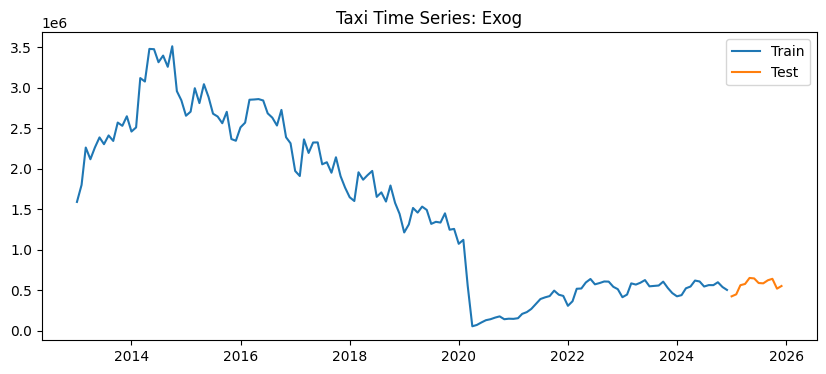

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


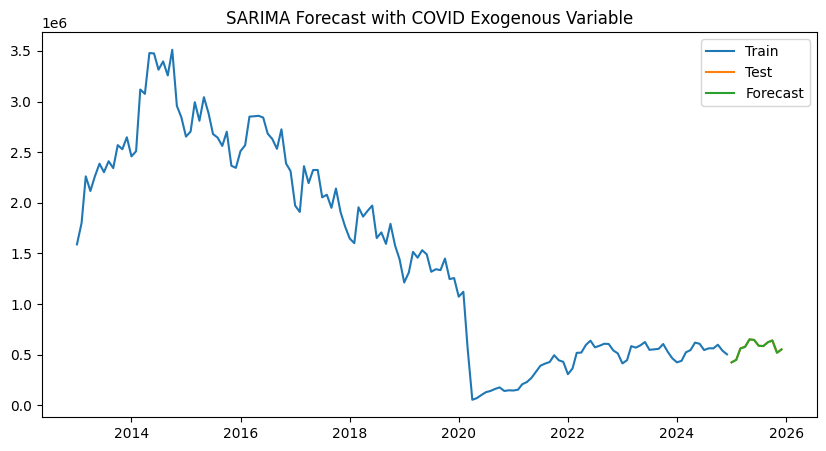

MAE: 0.0
RMSE: 0.0


In [ ]:
# can we improve performance more using exog variable?

monthly_rides_trim_cp = monthly_rides_trim.copy()

# create regressor for later
monthly_rides_trim_cp["lockdown"] = (
    (monthly_rides_trim["month"] >= "2020-03-01") &
    (monthly_rides_trim["month"] <= "2020-05-01")
).astype(int)

monthly_rides_trim_cp["post_covid"] = (monthly_rides_trim["month"] >= "2020-06-01").astype(int)
monthly_rides_trim_cp.tail()

ts_cov = monthly_rides_trim_cp.set_index("month")["num_trips"].asfreq("MS")
ts_cov = ts_cov.ffill()
ts_cov.head(), ts_cov.tail()

h = 12
train_cov, test_cov = ts_cov.iloc[:-h], ts_cov.iloc[-h:]

train_exog = ts_cov.iloc[:-h].to_frame()
test_exog = ts_cov.iloc[-h:].to_frame()

plt.figure(figsize=(10,4))
plt.plot(train_cov, label="Train")
plt.plot(test_cov, label="Test")
plt.legend()
plt.title("Taxi Time Series: Exog")
plt.show()

best_order = (1,1,1)
best_seasonal = (1,1,1,12)

best_model = SARIMAX(
    train_cov,
    order=best_order,
    seasonal_order=best_seasonal,
    exog=train_exog,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_results = best_model.fit(disp=False)

# --- 4. Forecast ---
best_forecast = best_results.get_forecast(steps=len(test_cov), exog=test_exog)
best_pred = best_forecast.predicted_mean
conf_int = best_forecast.conf_int()

# --- 5. Evaluate ---
best_mae = mean_absolute_error(test_cov, best_pred)
best_rmse = np.sqrt(mean_squared_error(test_cov, best_pred))

# --- 6. Plot ---
plt.figure(figsize=(10,5))
plt.plot(train.index, train_cov, label='Train')
plt.plot(test.index, test_cov, label='Test')
plt.plot(test.index, best_pred, label='Forecast')
plt.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast with COVID Exogenous Variable")
plt.show()

print("MAE:", best_mae)
print("RMSE:", best_rmse)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


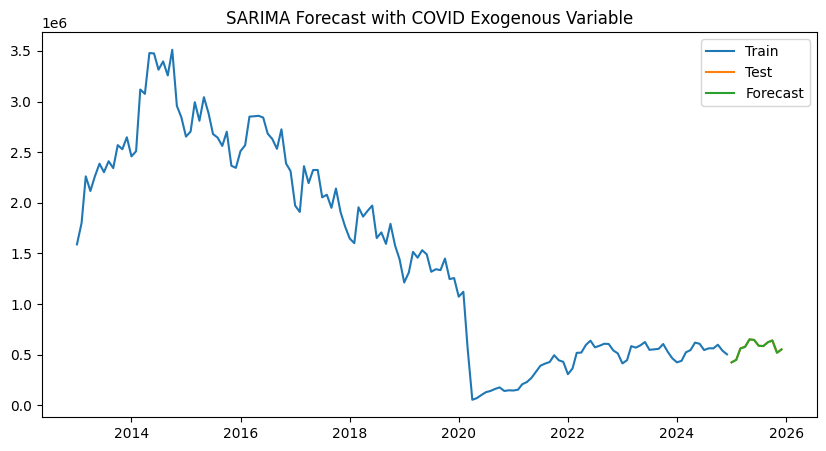

MAE: 0.0
RMSE: 0.0


In [ ]:
best_order = (1,1,1)
best_seasonal = (1,1,1,12)

best_model = SARIMAX(
    train_cov,
    order=best_order,
    seasonal_order=best_seasonal,
    exog=train_exog,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_results = best_model.fit(disp=False)

# --- 4. Forecast ---
best_forecast = best_results.get_forecast(steps=len(test_cov), exog=test_exog)
best_pred = best_forecast.predicted_mean
conf_int = best_forecast.conf_int()

# --- 5. Evaluate ---
best_mae = mean_absolute_error(test_cov, best_pred)
best_rmse = np.sqrt(mean_squared_error(test_cov, best_pred))

# --- 6. Plot ---
plt.figure(figsize=(10,5))
plt.plot(train.index, train_cov, label='Train')
plt.plot(test.index, test_cov, label='Test')
plt.plot(test.index, best_pred, label='Forecast')
plt.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast with COVID Exogenous Variable")
plt.show()

print("MAE:", best_mae)
print("RMSE:", best_rmse)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


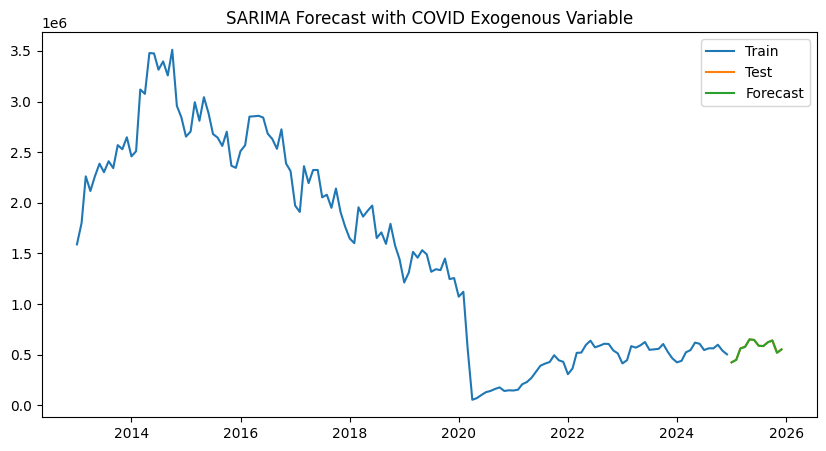

MAE: 0.0
RMSE: 0.0


In [ ]:
best_model = SARIMAX(
    train_cov,
    order=best_order,
    seasonal_order=best_seasonal,
    exog=train_exog,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_results = best_model.fit(disp=False)

best_forecast = best_results.get_forecast(steps=len(test_cov), exog=test_exog)
best_pred = best_forecast.predicted_mean
conf_int = best_forecast.conf_int()

best_mae = mean_absolute_error(test_cov, best_pred)
best_rmse = np.sqrt(mean_squared_error(test_cov, best_pred))

plt.figure(figsize=(10,5))
plt.plot(train_cov.index, train_cov, label='Train')
plt.plot(test_cov.index, test_cov, label='Test')
plt.plot(test_cov.index, best_pred, label='Forecast')
plt.fill_between(test_cov.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("SARIMA Forecast with COVID Exogenous Variable")
plt.show()

print("MAE:", best_mae)
print("RMSE:", best_rmse)

MAE: 17624.657711967768
RMSE: 21513.419508664334


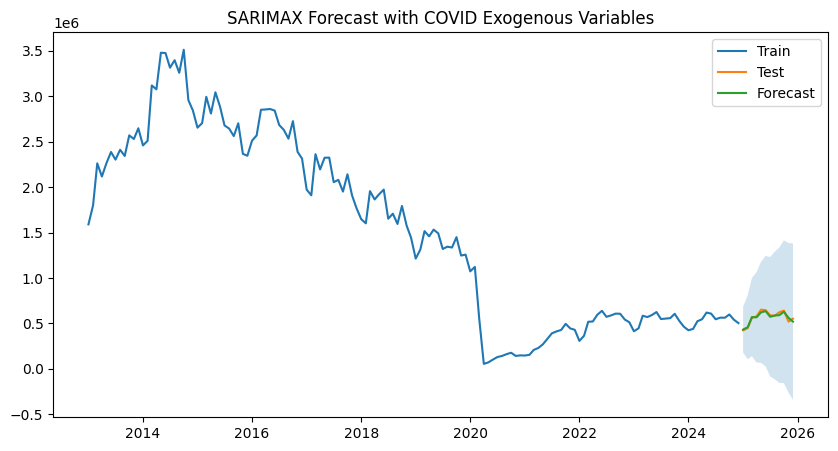

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Create copy ---
monthly_rides_trim_cp = monthly_rides_trim.copy()

# --- 2. Create exogenous variables ---
monthly_rides_trim_cp["lockdown"] = (
    (monthly_rides_trim_cp["month"] >= "2020-03-01") &
    (monthly_rides_trim_cp["month"] <= "2020-05-01")
).astype(int)

monthly_rides_trim_cp["post_covid"] = (
    monthly_rides_trim_cp["month"] >= "2020-06-01"
).astype(int)

ts_full = monthly_rides_trim_cp.set_index("month").asfreq("MS").ffill()

y = ts_full["num_trips"]

exog = ts_full[["lockdown", "post_covid"]]

h = 12

train_y, test_y = y.iloc[:-h], y.iloc[-h:]
train_exog, test_exog = exog.iloc[:-h], exog.iloc[-h:]

best_order = (1,1,1)
best_seasonal = (1,1,1,12)

model = SARIMAX(
    train_y,
    order=best_order,
    seasonal_order=best_seasonal,
    exog=train_exog,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

forecast_obj = results.get_forecast(
    steps=len(test_y),
    exog=test_exog
)

pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

mae = mean_absolute_error(test_y, pred)
rmse = np.sqrt(mean_squared_error(test_y, pred))

print("MAE:", mae)
print("RMSE:", rmse)

plt.figure(figsize=(10,5))
plt.plot(train_y.index, train_y, label="Train")
plt.plot(test_y.index, test_y, label="Test")
plt.plot(test_y.index, pred, label="Forecast")
plt.fill_between(
    test_y.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.2
)
plt.legend()
plt.title("SARIMAX Forecast with COVID Exogenous Variables")
plt.show()